###Architectuaral Feature Detect

Import

In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

Define dataset paths

In [11]:
DATASET_PATH = "Data"  # Update if needed
TRAIN_PATH = os.path.join(DATASET_PATH, "train")
TEST_PATH = os.path.join(DATASET_PATH, "test")

Define parameters

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20

Data Augmentation

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

Load dataset

In [15]:
train_dataset = train_datagen.flow_from_directory(
    TRAIN_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse'
)

test_dataset = test_datagen.flow_from_directory(
    TEST_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse'
)


Found 530 images belonging to 16 classes.
Found 148 images belonging to 16 classes.


Get number of classes

In [16]:
class_names = list(train_dataset.class_indices.keys())
num_classes = len(class_names)

 Load MobileNetV2 Model (Pretrained on ImageNet)

In [17]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model layers

Custom Classification Head

In [18]:

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

# Define final model
model = Model(inputs=base_model.input, outputs=outputs)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Early Stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

f:\anaconda\envs\coinenv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.3375 - loss: 2.5112 - val_accuracy: 0.4392 - val_loss: 1.8392
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.4789 - loss: 1.7443 - val_accuracy: 0.5541 - val_loss: 1.5337
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5603 - loss: 1.4456 - val_accuracy: 0.6689 - val_loss: 1.2999
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 976ms/step - accuracy: 0.6418 - loss: 1.2359 - val_accuracy: 0.6419 - val_loss: 1.2102
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 957ms/step - accuracy: 0.6870 - loss: 1.0198 - val_accuracy: 0.7365 - val_loss: 1.0709
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 947ms/step - accuracy: 0.7063 - loss: 0.9875 - val_accuracy: 0.7432 - val_loss: 0.9622
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 963ms/step - accuracy: 0.7324 - loss: 0.8868 - val_accuracy: 0.7432 - val_loss: 0.8836
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7600 - loss: 0.8513 - val_accuracy: 0.7635

Plot accuracy and loss

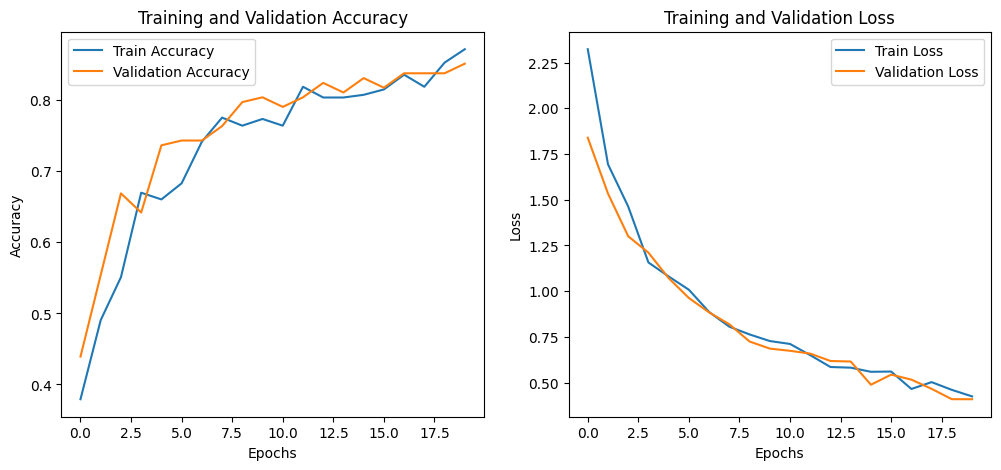

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

Model Evaluation

In [20]:
y_true = test_dataset.classes
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 763ms/step
Classification Report:
                  precision    recall  f1-score   support

          archer       0.00      0.00      0.00         2
 ceiling carving       0.00      0.00      0.00         5
  corner carving       0.00      0.00      0.00         8
   door carvings       0.18      0.18      0.18        11
        elephant       0.00      0.00      0.00         5
            fish       0.00      0.00      0.00         2
       ganapathi       0.00      0.00      0.00         2
        mahaveer       0.00      0.00      0.00         5
          monkey       0.09      0.11      0.10         9
  pillar carving       0.24      0.19      0.21        21
pillar sculpture       0.23      0.28      0.25        47
            star       0.00      0.00      0.00         2
           story       0.29      0.31      0.30        13
           tiger       0.00      0.00      0.00         2
        wall art       0.09      0.10      0.10        10
         

f:\anaconda\envs\coinenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
f:\anaconda\envs\coinenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
f:\anaconda\envs\coinenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Plot confusion matrix

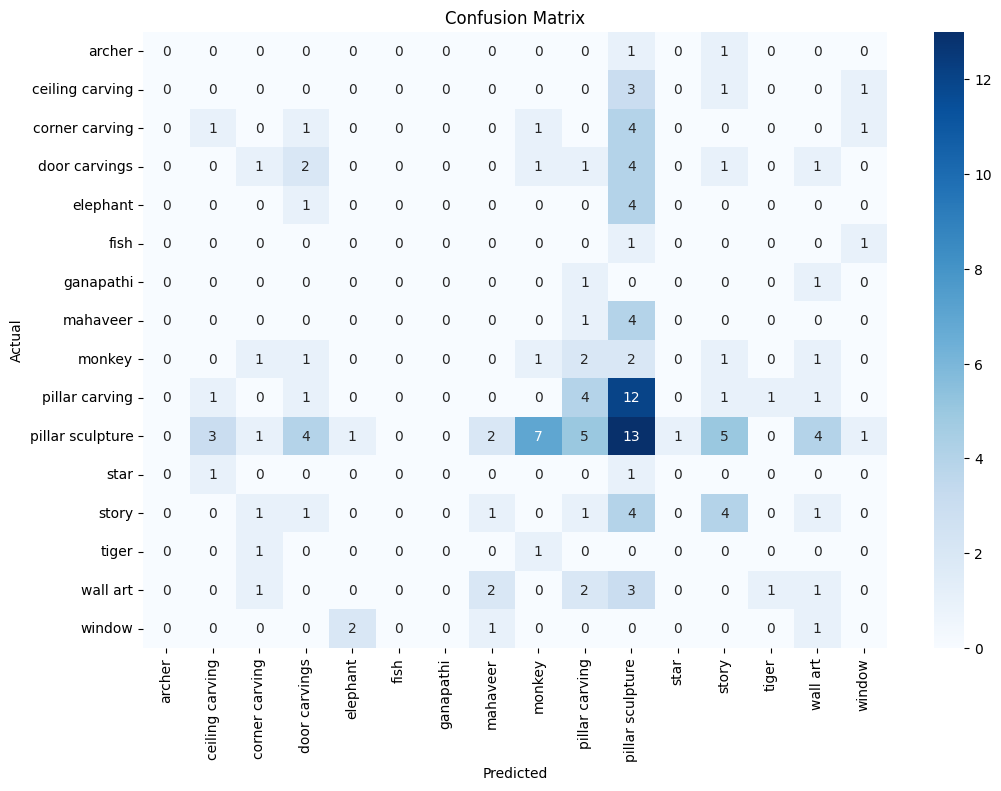

In [21]:
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Save the trained model

In [22]:
model.save("architectural_model.h5")
print("Model saved as architectural_model.h5")

Model saved as architectural_model.h5


Inference Function

In [24]:
def predict_image(image_path, model_path="architectural_model.h5"):
    from tensorflow.keras.models import load_model  # Ensure function imports model correctly
    from tensorflow.keras.preprocessing.image import load_img, img_to_array  # Ensure image functions are imported
    try:
        model = load_model(model_path)
        img = load_img(image_path, target_size=IMG_SIZE)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize
        prediction = model.predict(img_array)
        predicted_class = np.argmax(prediction)
        class_name = class_names[predicted_class]
        confidence = prediction[0][predicted_class]
        print(f"Predicted Class: {class_name} (Confidence: {confidence:.2f})")
        return class_name, confidence
    except Exception as e:
        print(f"Error during prediction: {e}")
        return None, None


Example usage

In [26]:
predict_image("Data/test/ceiling carving/IMG_20241009_113626_jpg.rf.4af1d0b677951ee9b27e0e5fc61b7e5d.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: ceiling carving (Confidence: 1.00)


('ceiling carving', np.float32(0.9965295))